# MCDI505 — Análisis de series de tiempo

## Consumo eléctrico del litoral


**Integrantes:** Luis Rodrigo Espinoza  
**Docente:** Dr. Harvey Jezlid Rosas Quintero 
**Datos:** `../data/raw/consumo_electrico_litoral.csv`  
**Figuras:** `../results/figures/`  
**Fecha:** 02 de octubre de 2026

**Propósito.**  

Analizar exploratoriamente una serie temporal de consumo eléctrico mensual, identificando sus principales patrones estructurales mediante visualización, descomposición y análisis de autocorrelación. El objetivo es reconocer la presencia de tendencia, estacionalidad, ciclos y variaciones residuales, y relacionar estos comportamientos con las funciones ACF y PACF como base para un modelamiento posterior.
Descripción del dataset. Se utiliza el conjunto de datos consumo_electrico_litoral.csv, compuesto por 120 observaciones mensuales comprendidas entre enero de 2015 y diciembre de 2024. El dataset contiene las variables fecha, consumo_gwh, clientes_comerciales, temperatura_media_c y dias_habiles. Para este análisis, la variable principal corresponde a consumo_gwh, que representa el consumo eléctrico mensual expresado en GWh. 

La serie presenta tres valores faltantes en dicha variable, los cuales deberán ser tratados antes de aplicar la descomposición y el análisis de autocorrelación.



***REPRODUCIBILIDAD.***

# 02 Carga y preparación de los datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# leer el archivo CSV y parsear la columna de fechas
df = pd.read_csv("../data/raw/consumo_electrico_litoral.csv", parse_dates=['fecha'])
# establecer la columna de fechas como índice y cambiar la frecuencia a mensual
df = df.set_index('fecha').asfreq('MS')
# mostrar las primeras filas del DataFrame
df.head()


,consumo_gwh,clientes_comerciales,temperatura_media_c,dias_habiles
fecha,,,,
2015-01-01,108.32,41827,19.6,22
2015-02-01,94.71,41918,18.7,20
2015-03-01,89.52,42045,16.5,22
2015-04-01,82.24,42129,13.3,22
2015-05-01,82.60,42242,12.0,21


### información general del DataFrame

In [2]:
# información general del DataFrame
df.info()
# estadísticas descriptivas del DataFrame
df.isnull().sum()

df.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 120 entries, 2015-01-01 to 2024-12-01
Freq: MS
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   consumo_gwh           117 non-null    float64
 1   clientes_comerciales  120 non-null    int64  
 2   temperatura_media_c   120 non-null    float64
 3   dias_habiles          120 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 4.7 KB


,consumo_gwh,clientes_comerciales,temperatura_media_c,dias_habiles
count,117.000000,120.000000,120.000000,120.000000
mean,104.612137,49389.591667,15.700000,21.741667
std,13.645166,4581.499820,3.186236,0.948203
min,73.190000,41827.000000,10.500000,20.000000
25%,95.740000,45269.500000,12.600000,21.000000
50%,102.940000,49761.500000,15.350000,22.000000
75%,114.880000,53472.250000,18.400000,22.000000
max,145.820000,56885.000000,21.700000,23.000000


# 03 Exploración y gráfico de la serie**

### Esta serie tiene 3 valores faltantes, podemos tratarlos mediante interpolación lineal



In [3]:

# mediante interpolación lineal, podemos tratar los valores faltantes de la serie

serie = df["consumo_gwh"].interpolate("time")

# 04 Exploración y gráfico de la serie

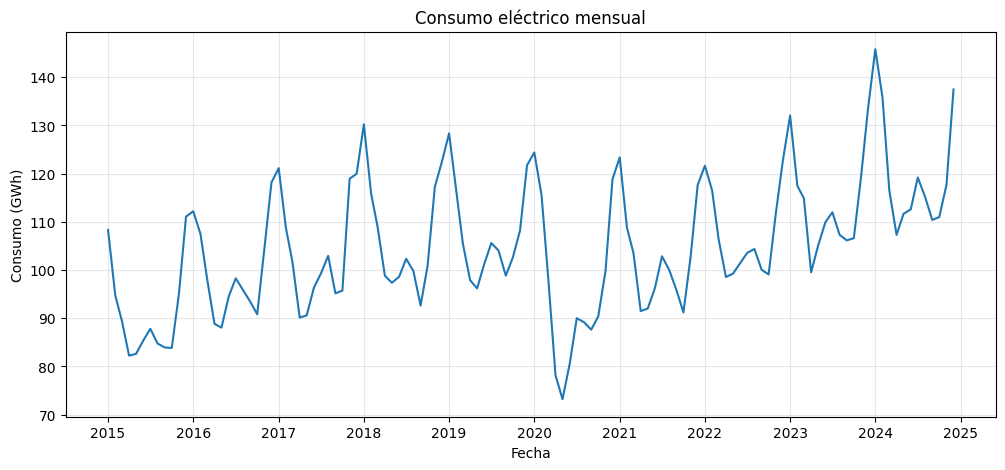

In [4]:
# Exploración y gráfico de la serie

# figura de tamaño 12x5
plt.figure(figsize=(12, 5))
# gráfico de la serie
plt.plot(serie)
# título y etiquetas de los ejes
plt.title("Consumo eléctrico mensual")
# etiquetas de los ejes
plt.xlabel("Fecha")
# etiquetas de los ejes
plt.ylabel("Consumo (GWh)")
# mostrar la cuadrícula
plt.grid(alpha=0.3)
# mostrar el gráfico
plt.show()


### ¿Sube o baja a largo plazo?
### ¿Se repiten patrones aproximadamente cada 12 meses?
### ¿Ves períodos anormales?
### ¿La amplitud parece aumentar con el nivel?
### ¿Parece haber ciclos o cambios de nivel?



# 05 Descomposición de la serie

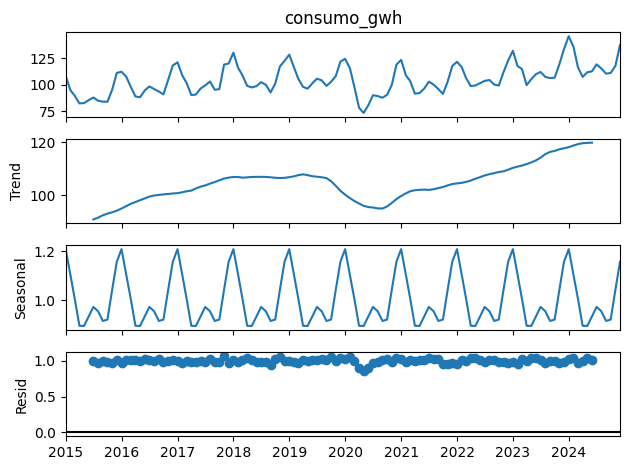

In [5]:
#aca se descompone la serie en sus componentes: tendencia, estacionalidad y residuo
descomposicion = seasonal_decompose(serie, model='multiplicative', period=12 )


# descomposición de la serie
descomposicion.plot()

# mostrar el gráfico
plt.show()

Interpretación. La descomposición muestra una tendencia creciente en el consumo eléctrico, interrumpida por una disminución durante 2020. También se identifica un patrón estacional que se repite anualmente. Los residuos permanecen principalmente alrededor de 1, salvo algunas variaciones puntuales, especialmente en 2020.

**Observed:**

La serie presenta una tendencia general creciente y un patrón que se repite cada año. Se observa además una caída importante alrededor de 2020.

**Trend:**

La tendencia aumenta entre 2015 y 2019, disminuye durante 2020 y posteriormente vuelve a crecer hasta 2024.

**Seasonal:**

Se observa una estacionalidad anual clara, con un patrón similar que se repite aproximadamente cada 12 meses.

**Resid:**

Los residuos se mantienen mayoritariamente cercanos a 1, aunque se observa una alteración más marcada durante 2020.

# 06 ACF y PACF

In [ ]:
# aca se grafican la ACF y PACF de la serie

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# ACF
plot_acf(serie, ax=axes[0], lags=36)
# PACF
plot_pacf(serie, ax=axes[1], lags=36, method='ywm')

# layout ajustado para evitar solapamiento de elementos

plt.tight_layout()

# mostrar el gráfico
plt.show()


